#📊 Global Sales Analysis Project
###Data Cleaning, Analysis, and Visualization with Python


This project analyzes a global sales dataset that includes:

- **events.csv**: sales transactions  
- **products.csv**: product catalog  
- **countries.csv**: country and region information  

The goal is to clean the data, perform exploratory analysis, and extract relevant insights from a business perspective.


## 1. Overview of the Data

We load the three tables and examine their structure: number of rows and columns,
data types, and the first rows of each table.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Data loading
events = pd.read_csv('/content/drive/MyDrive/Portfolio/Colab_notebooks/Project2/Dataset/events.csv')
products = pd.read_csv('/content/drive/MyDrive/Portfolio/Colab_notebooks/Project2/Dataset/products.csv')
countries = pd.read_csv('/content/drive/MyDrive/Portfolio/Colab_notebooks/Project2/Dataset/countries.csv')

Mounted at /content/drive


### 1.1 Dimensions and Data Types

We examine the number of rows, columns, and the data type of each field in the three tables.


In [2]:
for name, table in [("events", events), ("products", products), ("countries", countries)]:
    print(f"{'='*40}")
    print(f"Table: {name} — {table.shape[0]} rows, {table.shape[1]} columns")
    print(table.dtypes)
    print()

Table: events — 1330 rows, 10 columns
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object

Table: products — 12 rows, 2 columns
id            int64
item_type    object
dtype: object

Table: countries — 249 rows, 5 columns
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object



### 1.2 First Rows of Each Table

We review the first rows to understand the content and structure of each dataset.

In [3]:
print("EVENTS")
display(events.head())

print("PRODUCTS")
display(products.head())

print("COUNTRIES")
display(countries.head())

EVENTS


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


PRODUCTS


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


COUNTRIES


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


## 2. Data Cleaning

### 2.1 Missing Values

We analyze how many null values exist in each table and what proportion they represent
relative to the total number of rows.

In [4]:
for name, table in [("events", events), ("products", products), ("countries", countries)]:
    nulls = table.isna().sum()
    percentage = (nulls / len(table) * 100).round(2)
    summary = pd.DataFrame({"Nulls": nulls, "Percentage %": percentage})
    summary = summary[summary["Nulls"] > 0]

    print(f"Table: {name}")
    if summary.empty:
        print("  No missing values\n")
    else:
        display(summary)
        print()

Table: events


,Nulls,Percentage %
Country Code,82,6.17
Units Sold,2,0.15



Table: products
  No missing values

Table: countries


,Nulls,Percentage %
alpha-2,1,0.4
region,1,0.4
sub-region,1,0.4


### 2.2 Investigation of Missing Values

We inspect the records with missing values to understand their origin
and decide how to handle them.


In [6]:
# Row with nulls in countries
print("Record with nulls in countries:")
display(countries[countries.isna().any(axis=1)])

# Rows with nulls in Units Sold
print("Records with nulls in Units Sold:")
display(events[events["Units Sold"].isna()])

# How many Country Code nulls exist and how they are distributed
print(f"\nTotal nulls in Country Code: {events['Country Code'].isna().sum()}")

Record with nulls in countries:


,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


Records with nulls in Units Sold:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67



Total nulls in Country Code: 82


### 2.3 Treatment of Missing Values

We apply the following decisions:
- **Antarctica** (countries): removed because it is not an operational market.
- **Namibia** (countries): the `alpha-2` field is filled with its correct ISO code `NA`.
- **Units Sold** (events): the 2 records without units sold are removed.
- **Country Code** (events): filled with `"Unknown"` to preserve the rest of the order data.

In [7]:
# 1. Remove Antarctica
countries = countries[countries["name"] != "Antarctica"].reset_index(drop=True)

# 2. Fill Namibia alpha-2 code
countries.loc[countries["name"] == "Namibia", "alpha-2"] = "NA"

# 3. Remove rows without Units Sold
events = events.dropna(subset=["Units Sold"]).reset_index(drop=True)

# 4. Fill null Country Code with "Unknown"
events["Country Code"] = events["Country Code"].fillna("Unknown")

# Verification
print("Remaining nulls in events:")
print(events.isna().sum())
print(f"\nRows in events after cleaning: {len(events)}")
print(f"\nRemaining nulls in countries:")
print(countries.isna().sum())

Remaining nulls in events:
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64

Rows in events after cleaning: 1328

Remaining nulls in countries:
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64


### 2.4 Data Types

We verify that each column has the correct data type.
We detect that `Order Date` and `Ship Date` are `object` (text) instead of `datetime`,
and that `Units Sold` is `float64` instead of `int64`.

In [8]:
# Convert dates to datetime
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

# Convert Units Sold to integer
events["Units Sold"] = events["Units Sold"].astype(int)

# Verification
print(events.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold                 int64
Unit Price               float64
Unit Cost                float64
dtype: object


### 2.5 Duplicates

We search for duplicate rows in the three tables. Duplicates may appear
due to extra spaces, differences in uppercase/lowercase, or other hidden characters.

In [9]:
for name, table in [("events", events), ("products", products), ("countries", countries)]:
    duplicates = table.duplicated().sum()
    print(f"Table {name}: {duplicates} duplicates")

Table events: 0 duplicates
Table products: 0 duplicates
Table countries: 0 duplicates


### 2.6 Anomalies

We investigate whether there are anomalous values in the numerical columns:
negative prices, zero units sold, or shipping dates earlier than the order date.

In [10]:
# Negative or zero values in numerical columns
print("Units Sold <= 0:", (events["Units Sold"] <= 0).sum())
print("Unit Price <= 0:", (events["Unit Price"] <= 0).sum())
print("Unit Cost <= 0:", (events["Unit Cost"] <= 0).sum())

# Shipping dates earlier than order dates
envio_antes = events[events["Ship Date"] < events["Order Date"]]
print(f"\nOrders with Ship Date earlier than Order Date: {len(envio_antes)}")
if len(envio_antes) > 0:
    display(envio_antes.head())

# Date range
print(f"\nEarliest date: {events['Order Date'].min()}")
print(f"Latest date: {events['Order Date'].max()}")

Units Sold <= 0: 0
Unit Price <= 0: 0
Unit Cost <= 0: 0

Orders with Ship Date earlier than Order Date: 0

Earliest date: 2010-01-01 00:00:00
Latest date: 2017-07-23 00:00:00


### 2.7 Cleaning Summary

- Removed 2 orders without `Units Sold`
- Removed 1 record of Antarctica from `countries`
- Filled 82 null values in `Country Code` → `"Unknown"`
- Corrected Namibia `alpha-2` code → `"NA"`
- Converted `Order Date` and `Ship Date` to `datetime64`
- Converted `Units Sold` to `int64`
- No duplicates found in any table
- No anomalies detected

The final `events` dataset contains **1,328 orders** ready for analysis.

## 3. Data Analysis and Visualization

### 3.1 Table Joining

We combine the three tables into a single DataFrame so we can analyze
all dimensions together: product, geography, and sales channel.

In [11]:
# Rename columns before merging
products = products.rename(columns={"id": "Product ID", "item_type": "Category"})
countries = countries.rename(columns={"name": "Country", "alpha-3": "Country Code",
                                       "alpha-2": "alpha-2", "region": "Region",
                                       "sub-region": "Sub-Region"})

# Merge events + products
df = events.merge(products, on="Product ID", how="left")

# Merge with countries (only those with known code)
df = df.merge(countries[["Country Code", "Country", "Region", "Sub-Region"]],
              on="Country Code", how="left")

# Remove unnecessary columns
df = df.drop(columns=["Product ID"])

# Verification
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
display(df.head())

Rows: 1328 | Columns: 13


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,Online,4693,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


### 3.2 Calculated Columns

We add the necessary columns for financial and time-based analysis:
- **Revenue**: total revenue per order (units × price)
- **Cost**: total cost per order (units × unit cost)
- **Profit**: profit per order (revenue − cost)
- **Shipping Days**: days between order and shipment

In [12]:
df["Revenue"] = df["Units Sold"] * df["Unit Price"]
df["Cost"] = df["Units Sold"] * df["Unit Cost"]
df["Profit"] = df["Revenue"] - df["Cost"]
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(df[["Revenue", "Cost", "Profit", "Shipping Days"]].describe().round(2))

          Revenue        Cost      Profit  Shipping Days
count     1328.00     1328.00     1328.00        1328.00
mean   1281723.95   904137.76   377586.19          24.79
std    1443862.58  1135504.30   369121.62          14.59
min        503.82      373.68      130.14           0.00
25%     266410.47   157606.87    84912.85          12.00
50%     761304.88   433223.28   274868.02          25.00
75%    1743177.28  1108768.02   547736.60          37.00
max    6672675.95  5248025.12  1700448.60          50.00


### 3.3 Key Business Metrics (KPIs)

We calculate the main performance indicators of the company's global operations:
total orders, revenue, costs, profit, countries covered, and average profit margin.

In [13]:
total_orders = df["Order ID"].nunique()
total_revenue = df["Revenue"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
total_countries = df[df["Country Code"] != "Unknown"]["Country Code"].nunique()
avg_margin = (df["Profit"] / df["Revenue"]).mean() * 100

print(f"Total orders: {total_orders:,.0f}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Total cost: ${total_cost:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Countries covered: {total_countries}")
print(f"Profit margin: {avg_margin:.1f}%")

Total orders: 1,328
Total revenue: $1,702,129,408.21
Total cost: $1,200,694,949.21
Total profit: $501,434,459.00
Countries covered: 45
Profit margin: 34.1%


### 3.4 Analysis by Product Category

We analyze revenue, costs, and profit grouped by product category,
and identify the most profitable and popular categories.

In [14]:
by_category = df.groupby("Category").agg(
    Orders=("Order ID", "count"),
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Profit", "sum")
).sort_values("Profit", ascending=False).round(2)

by_category["Margin %"] = (by_category["Profit"] / by_category["Revenue"] * 100).round(1)

# Readable formatting for monetary columns
display(by_category.style.format({
    "Revenue": "${:,.0f}",
    "Cost": "${:,.0f}",
    "Profit": "${:,.0f}",
    "Margin %": "{:.1f}%"
}))

,Orders,Revenue,Cost,Profit,Margin %
Category,,,,,
Cosmetics,114,"$233,154,825","$140,431,519","$92,723,306",39.8%
Office Supplies,123,"$402,213,996","$324,236,819","$77,977,176",19.4%
Household,97,"$294,205,199","$221,242,732","$72,962,467",24.8%
Baby Food,112,"$143,647,588","$89,706,591","$53,940,997",37.6%
Clothes,105,"$64,626,553","$21,195,238","$43,431,314",67.2%
Cereal,103,"$95,791,404","$54,536,370","$41,255,034",43.1%
Vegetables,114,"$89,746,729","$52,970,726","$36,776,003",41.0%
Meat,110,"$223,762,018","$193,424,282","$30,337,736",13.6%
Snacks,103,"$74,788,613","$47,761,190","$27,027,422",36.1%


#### Visualization: Profit and Margin by Category

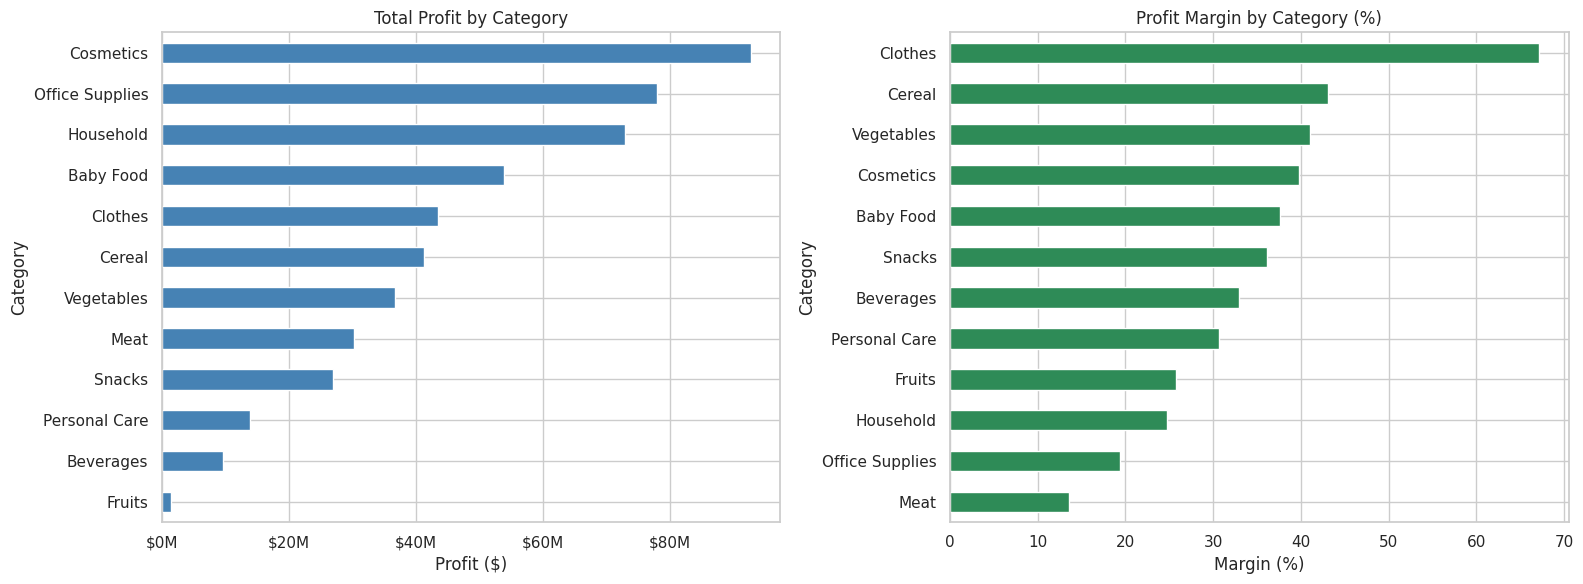

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Total profit by category
by_category["Profit"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Total Profit by Category")
axes[0].set_xlabel("Profit ($)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

# Chart 2: Margin % by category
by_category["Margin %"].sort_values().plot(
    kind="barh", ax=axes[1], color="seagreen"
)
axes[1].set_title("Profit Margin by Category (%)")
axes[1].set_xlabel("Margin (%)")

plt.tight_layout()
plt.show()

### 3.5 Geographic Analysis

We analyze revenue, costs, and profit grouped by region and country,
identifying the most profitable markets.

In [16]:
by_region = df[df["Region"].notna()].groupby("Region").agg(
    Orders=("Order ID", "count"),
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Profit", "sum")
).sort_values("Profit", ascending=False).round(2)

by_region["Margin %"] = (by_region["Profit"] / by_region["Revenue"] * 100).round(1)

display(by_region.style.format({
    "Revenue": "${:,.0f}",
    "Cost": "${:,.0f}",
    "Profit": "${:,.0f}",
    "Margin %": "{:.1f}%"
}))

,Orders,Revenue,Cost,Profit,Margin %
Region,,,,,
Europe,1164,"$1,505,652,874","$1,057,096,092","$448,556,782",29.8%
Asia,82,"$93,330,887","$68,178,634","$25,152,253",26.9%


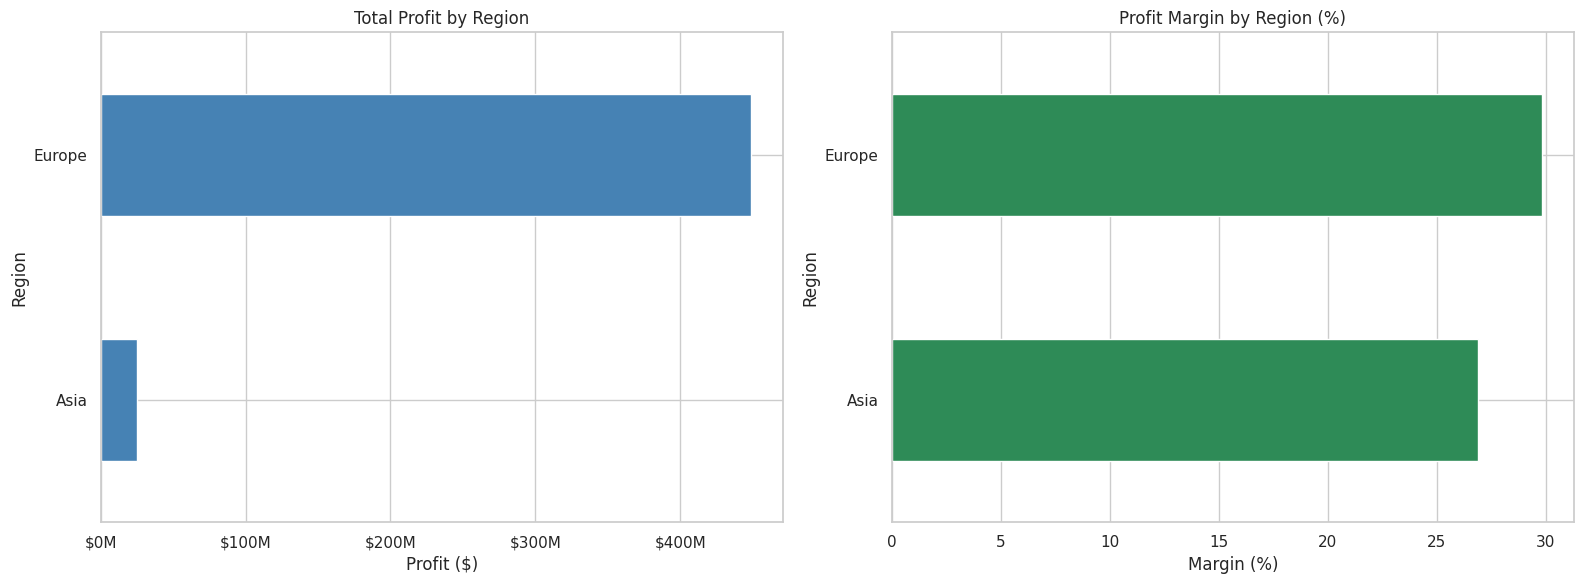

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Total profit by region
by_region["Profit"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Total Profit by Region")
axes[0].set_xlabel("Profit ($)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

# Chart 2: Profit margin by region
by_region["Margin %"].sort_values().plot(
    kind="barh", ax=axes[1], color="seagreen"
)
axes[1].set_title("Profit Margin by Region (%)")
axes[1].set_xlabel("Margin (%)")

plt.tight_layout()
plt.show()

#### Top 10 Countries by Profit

,Orders,Revenue,Profit,Margin %
Country,,,,
Andorra,40,"$47,756,693","$15,410,037",32.3%
Ukraine,33,"$53,252,318","$14,804,926",27.8%
Malta,32,"$47,145,321","$14,610,128",31.0%
San Marino,40,"$47,883,708","$13,792,993",28.8%
Hungary,25,"$42,408,249","$13,786,231",32.5%
Macedonia,32,"$49,222,085","$13,684,100",27.8%
Czech Republic,31,"$53,543,932","$13,635,594",25.5%
Russia,32,"$46,051,660","$13,267,683",28.8%
Bosnia and Herzegovina,33,"$50,117,508","$13,257,603",26.5%


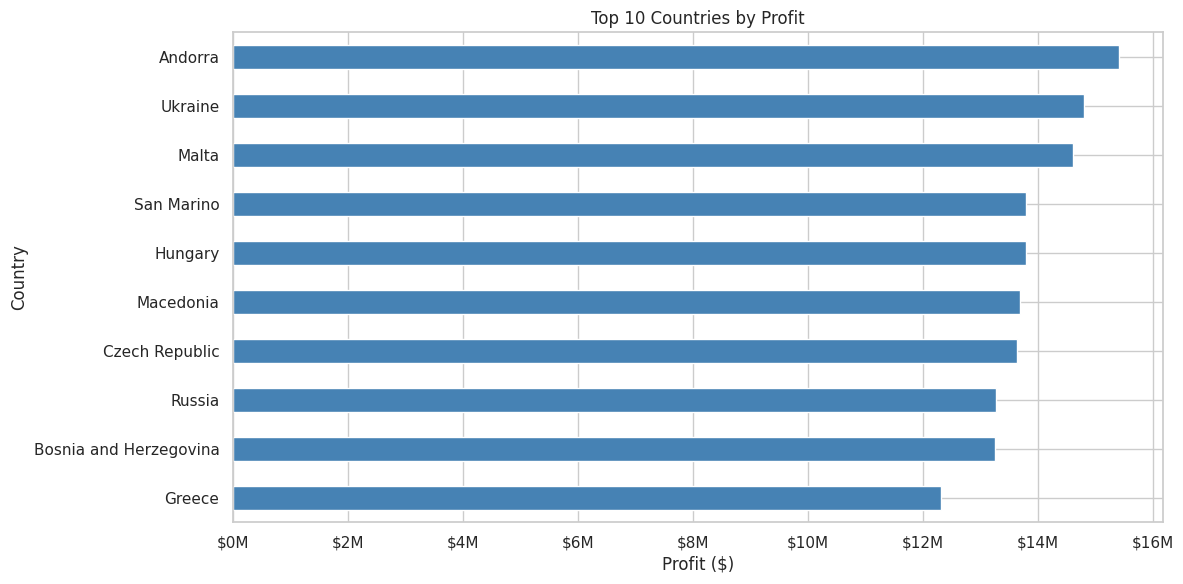

In [18]:
by_country = df[df["Country"].notna()].groupby("Country").agg(
    Orders=("Order ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).sort_values("Profit", ascending=False).head(10).round(2)

by_country["Margin %"] = (by_country["Profit"] / by_country["Revenue"] * 100).round(1)

display(by_country.style.format({
    "Revenue": "${:,.0f}",
    "Profit": "${:,.0f}",
    "Margin %": "{:.1f}%"
}))

# Chart
by_country["Profit"].sort_values().plot(
    kind="barh", figsize=(12, 6), color="steelblue"
)
plt.title("Top 10 Countries by Profit")
plt.xlabel("Profit ($)")
plt.xaxis = plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()

### 3.6 Sales Channel Analysis

We compare the performance of the Online vs. Offline channels in terms of
orders, revenue, and profit.

,Orders,Revenue,Cost,Profit,Margin %
Sales Channel,,,,,
Offline,665,"$871,760,624","$618,294,105","$253,466,519",29.1%
Online,660,"$824,789,270","$577,991,423","$246,797,847",29.9%
online,3,"$5,579,514","$4,409,421","$1,170,094",21.0%


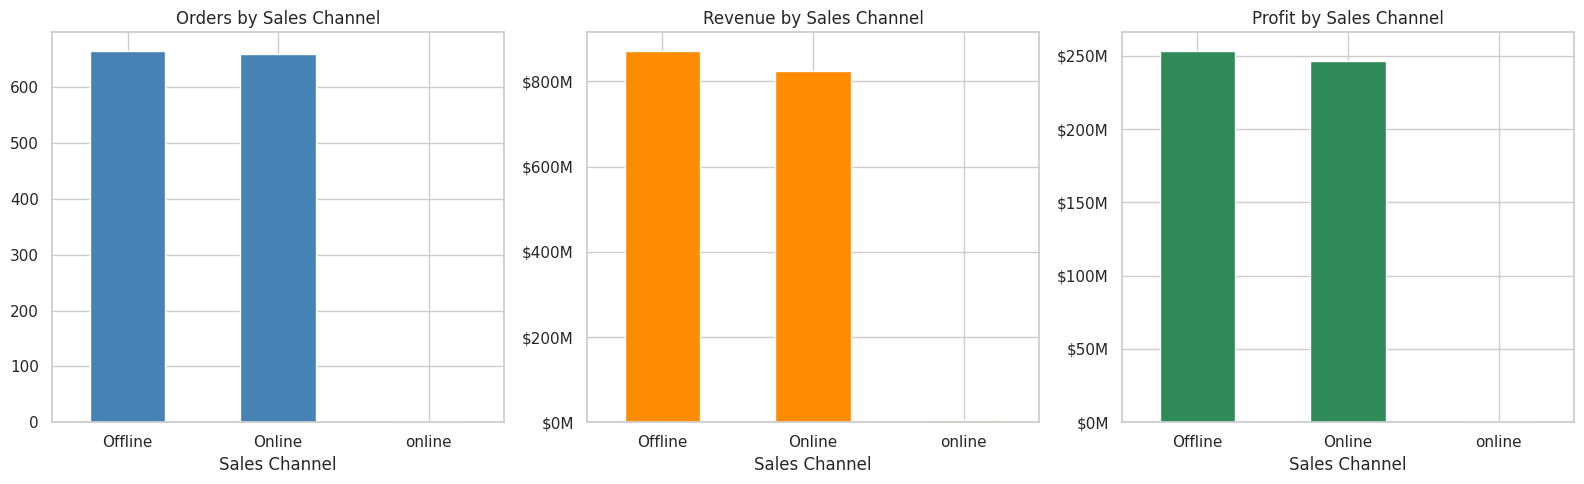

In [19]:
by_channel = df.groupby("Sales Channel").agg(
    Orders=("Order ID", "count"),
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Profit", "sum")
).round(2)

by_channel["Margin %"] = (by_channel["Profit"] / by_channel["Revenue"] * 100).round(1)

display(by_channel.style.format({
    "Revenue": "${:,.0f}",
    "Cost": "${:,.0f}",
    "Profit": "${:,.0f}",
    "Margin %": "{:.1f}%"
}))

# Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ["Orders", "Revenue", "Profit"],
                           ["steelblue", "darkorange", "seagreen"]):
    by_channel[col].plot(kind="bar", ax=ax, color=color, rot=0)
    ax.set_title(f"{col} by Sales Channel")
    if col != "Orders":
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

plt.tight_layout()
plt.show()

### 3.7 Shipping Time Analysis

We analyze the time interval in days between the order date and the shipping date,
broken down by product category, country, and region.

Average shipping time by category:


,Shipping Days
Category,
Cereal,27.2
Office Supplies,26.7
Baby Food,26.3
Cosmetics,25.9
Meat,25.9
Snacks,25.5
Fruits,24.4
Beverages,24.1
Household,23.9



Average shipping time by region:


,Shipping Days
Region,
Asia,26.1
Europe,24.8


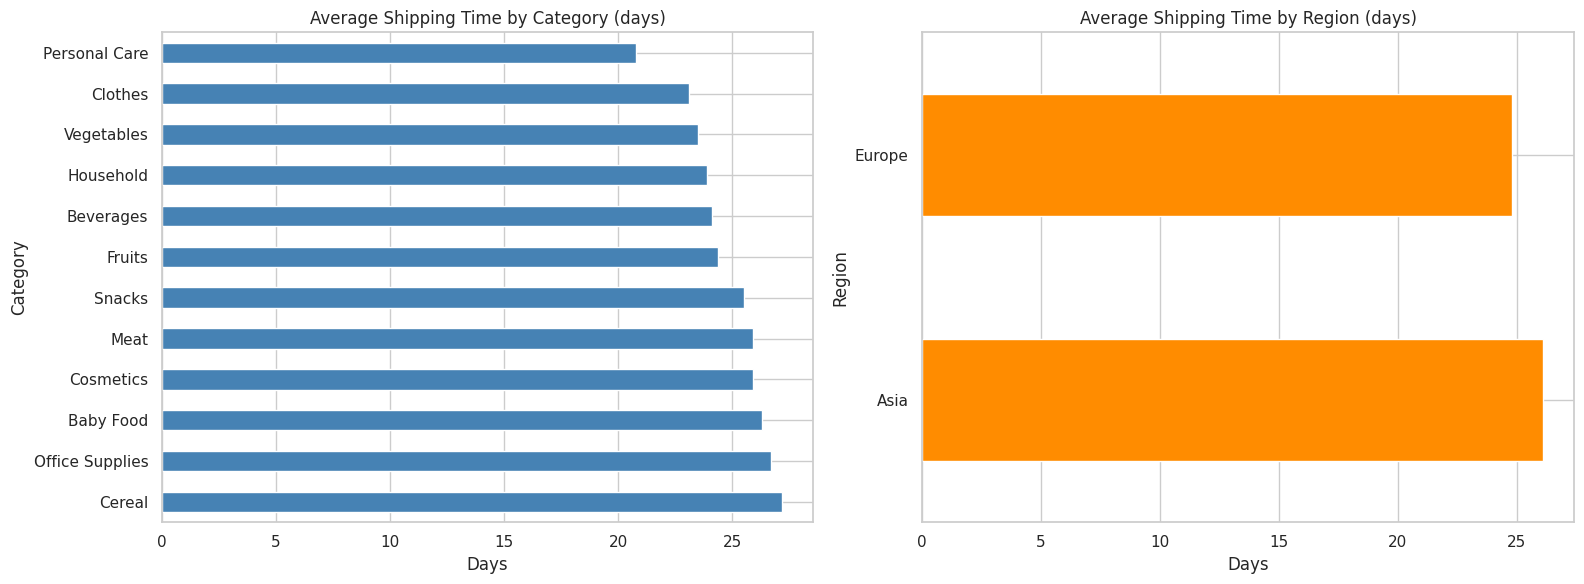

In [21]:
# By category
ship_category = df.groupby("Category")["Shipping Days"].mean().sort_values(ascending=False).round(1)

# By region
ship_region = df[df["Region"].notna()].groupby("Region")["Shipping Days"].mean().sort_values(ascending=False).round(1)

print("Average shipping time by category:")
display(ship_category)

print("\nAverage shipping time by region:")
display(ship_region)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ship_category.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Average Shipping Time by Category (days)")
axes[0].set_xlabel("Days")

ship_region.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Average Shipping Time by Region (days)")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

### 3.8 Does Profit Depend on Shipping Time?

We analyze whether there is any relationship between shipping days and
the profit generated per order.

Average profit by shipping days:


,Profit
Shipping Days,
0,348379.71
1,309541.68
2,339626.03
3,285222.78
4,300644.40
5,417644.89
6,366050.05
7,400718.31
8,344957.54


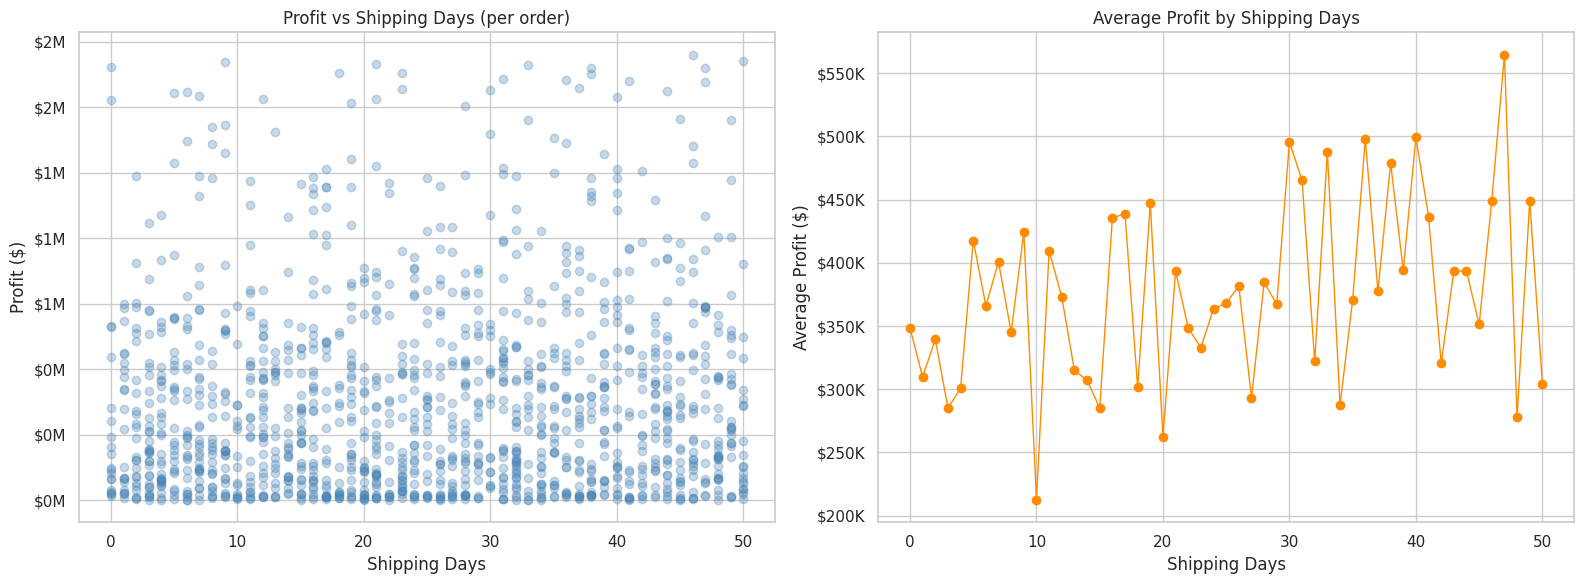

In [22]:
# Group by shipping days and calculate average profit
ship_profit = df.groupby("Shipping Days")["Profit"].mean().round(2)

print("Average profit by shipping days:")
display(ship_profit)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Profit vs Shipping Days
axes[0].scatter(df["Shipping Days"], df["Profit"], alpha=0.3, color="steelblue")
axes[0].set_title("Profit vs Shipping Days (per order)")
axes[0].set_xlabel("Shipping Days")
axes[0].set_ylabel("Profit ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

# Line plot: Average profit by shipping days
ship_profit.plot(ax=axes[1], color="darkorange", marker="o", linewidth=1)
axes[1].set_title("Average Profit by Shipping Days")
axes[1].set_xlabel("Shipping Days")
axes[1].set_ylabel("Average Profit ($)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))

plt.tight_layout()
plt.show()

**Conclusion:** No clear correlation is observed between shipping time
and profit per order. Orders with fast shipping (0–5 days) and slow shipping
(45–50 days) generate similar profits, suggesting that shipping time
is not a determining factor in profitability.

### 3.9 Sales Dynamics Over Time

We analyze the evolution of revenue and profit by year, and break down
the trends by product category and region.

,Orders,Revenue,Profit
Year,,,
2010,166,"$209,382,247","$61,422,460"
2011,175,"$231,937,557","$69,044,660"
2012,202,"$285,485,892","$87,884,066"
2013,158,"$182,962,359","$53,387,995"
2014,186,"$236,285,823","$71,189,626"
2015,160,"$227,954,099","$61,734,040"
2016,175,"$191,520,957","$57,771,921"
2017,106,"$136,600,474","$38,999,691"


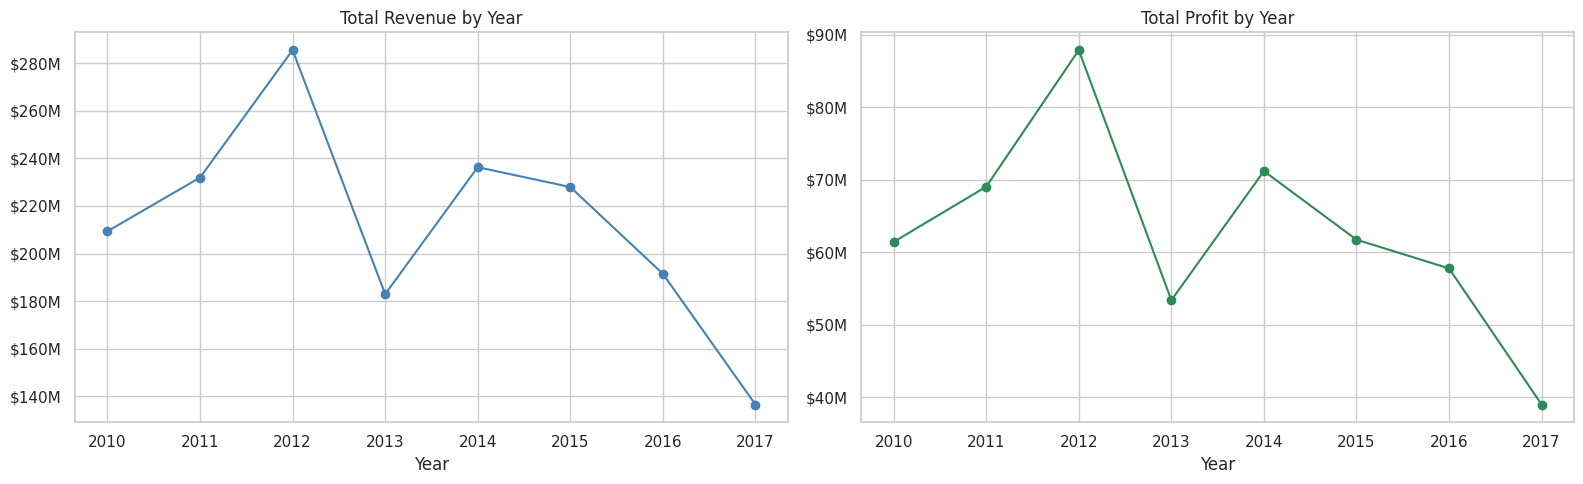

In [23]:
# Extract year
df["Year"] = df["Order Date"].dt.year

# By year
by_year = df.groupby("Year").agg(
    Orders=("Order ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).round(2)

display(by_year.style.format({
    "Revenue": "${:,.0f}",
    "Profit": "${:,.0f}"
}))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

by_year["Revenue"].plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("Total Revenue by Year")
axes[0].set_xlabel("Year")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

by_year["Profit"].plot(ax=axes[1], marker="o", color="seagreen")
axes[1].set_title("Total Profit by Year")
axes[1].set_xlabel("Year")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

plt.tight_layout()
plt.show()

#### 3.9.1 Sales Dynamics by Product Category Over Time

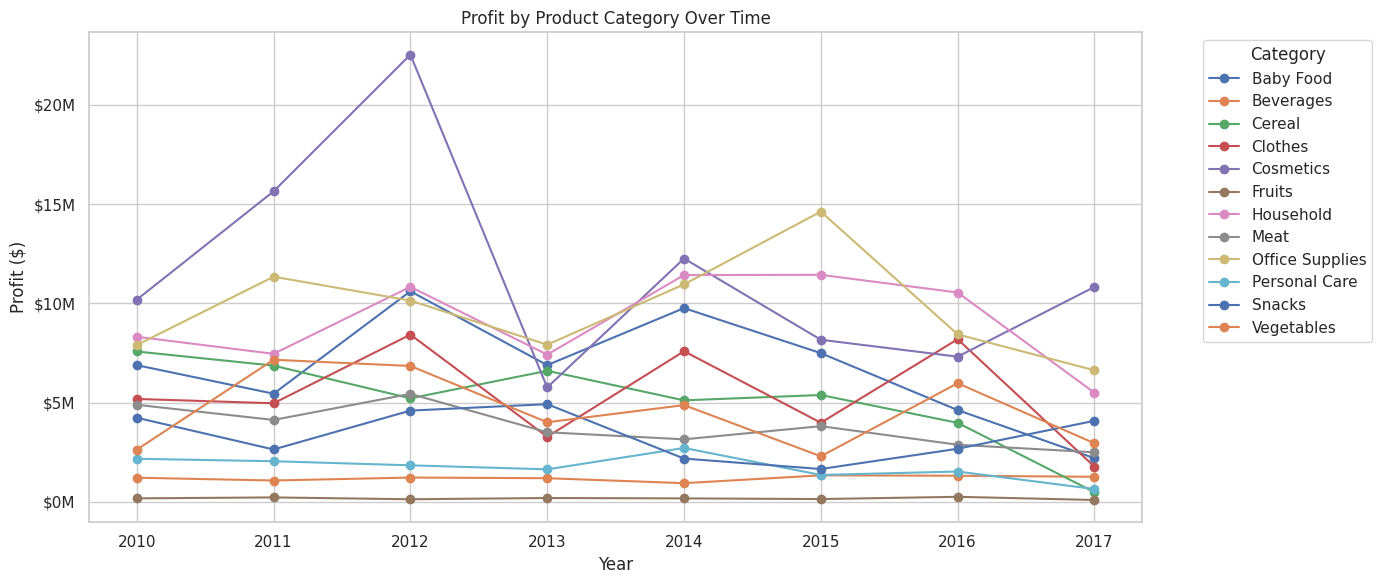

In [24]:
by_year_category = df.groupby(["Year", "Category"])["Profit"].sum().unstack().fillna(0)

by_year_category.plot(figsize=(14, 6), marker="o")
plt.title("Profit by Product Category Over Time")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.yaxis = plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 3.9.2 Sales Dynamics by Region Over Time

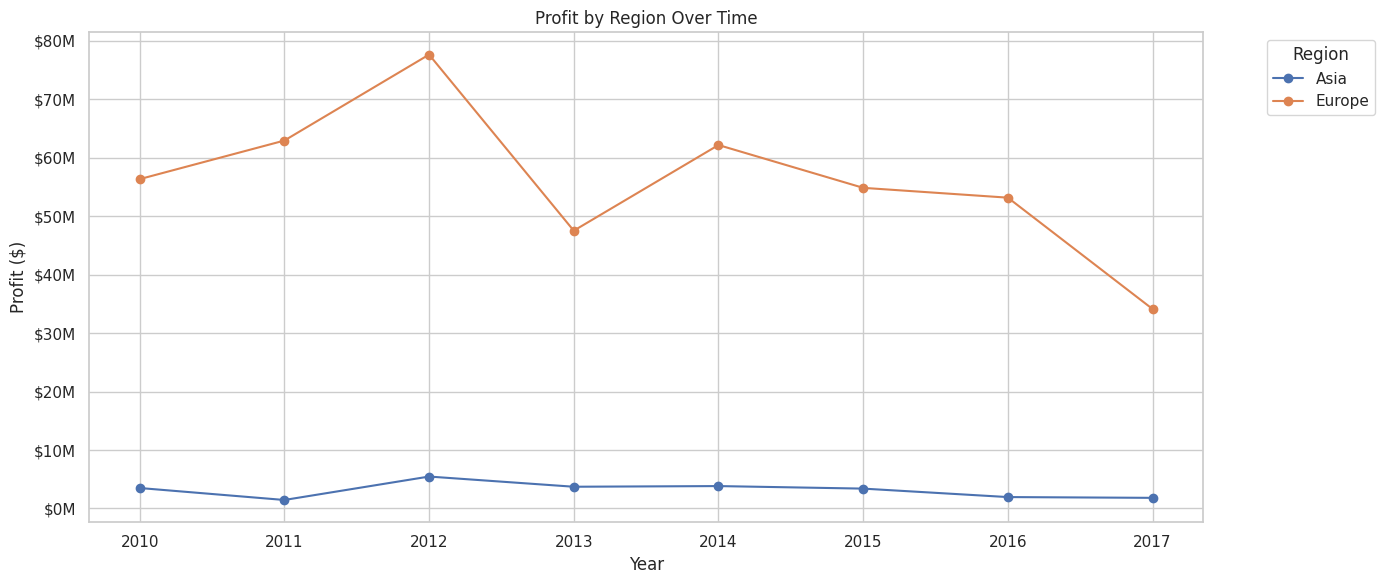

In [25]:
by_year_region = df[df["Region"].notna()].groupby(["Year", "Region"])["Profit"].sum().unstack().fillna(0)

by_year_region.plot(figsize=(14, 6), marker="o")
plt.title("Profit by Region Over Time")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3.10 Sales Analysis by Day of the Week

We analyze whether there is any pattern in sales depending on the day of the week
the order was placed, and whether any product category shows
seasonal behavior.

,Orders,Revenue,Profit
Day of Week,,,
Monday,201,"$275,468,476","$75,790,330"
Tuesday,182,"$213,523,895","$65,637,400"
Wednesday,194,"$261,215,697","$72,323,843"
Thursday,167,"$214,922,231","$64,325,663"
Friday,176,"$263,807,004","$79,234,529"
Saturday,201,"$233,641,145","$71,435,860"
Sunday,207,"$239,550,961","$72,686,833"


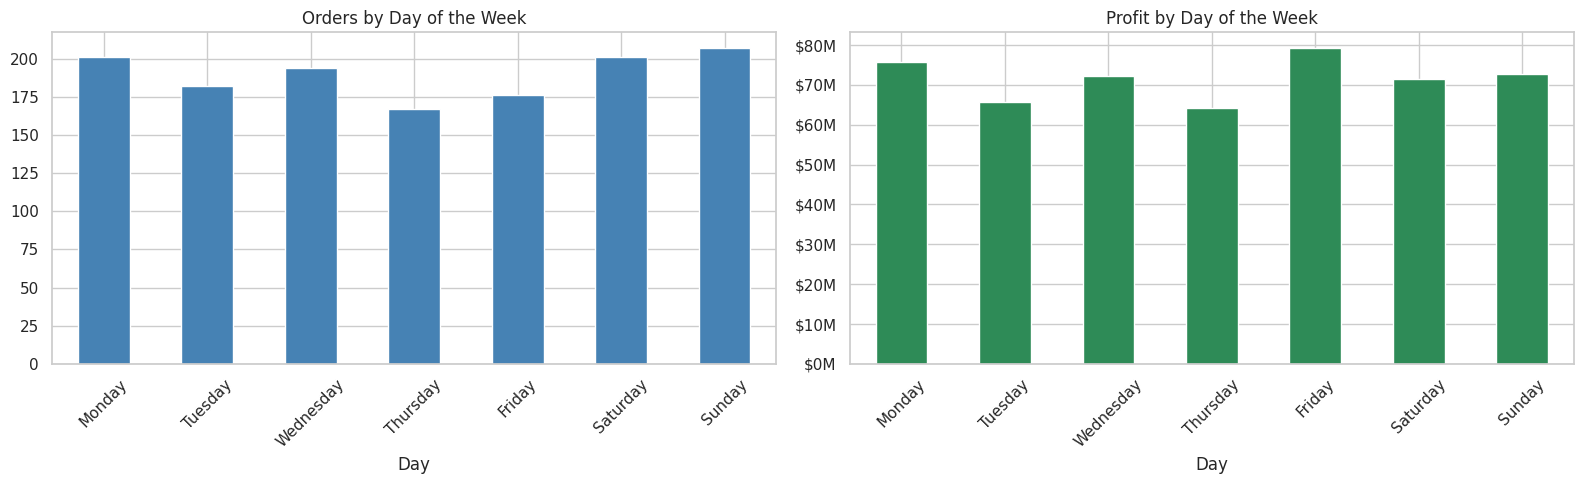

In [26]:
# Extract day of the week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Correct order of days
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

by_day = df.groupby("Day of Week").agg(
    Orders=("Order ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reindex(days_order).round(2)

display(by_day.style.format({
    "Revenue": "${:,.0f}",
    "Profit": "${:,.0f}"
}))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

by_day["Orders"].plot(kind="bar", ax=axes[0], color="steelblue", rot=45)
axes[0].set_title("Orders by Day of the Week")
axes[0].set_xlabel("Day")

by_day["Profit"].plot(kind="bar", ax=axes[1], color="seagreen", rot=45)
axes[1].set_title("Profit by Day of the Week")
axes[1].set_xlabel("Day")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

plt.tight_layout()
plt.show()

#### 3.10.1 Sales by Product Category and Day of the Week

We analyze whether any category shows seasonal behavior
depending on the day of the week.

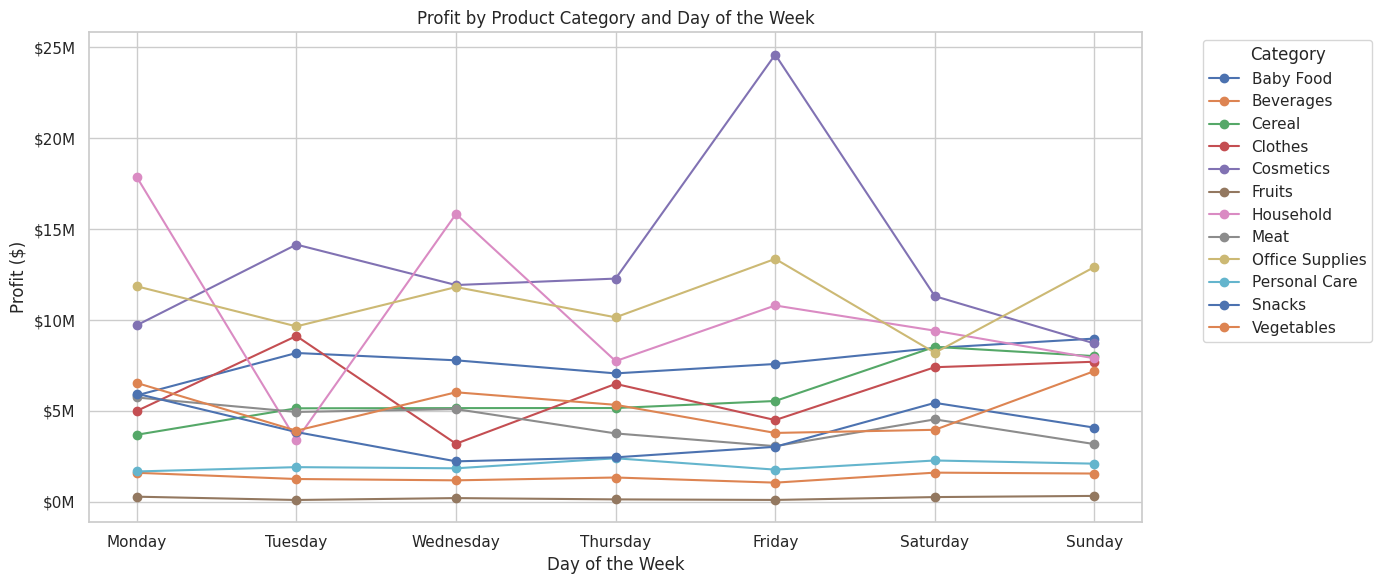

In [27]:
by_day_category = df.groupby(["Day of Week", "Category"])["Profit"].sum().unstack().fillna(0)
by_day_category = by_day_category.reindex(days_order)

by_day_category.plot(figsize=(14, 6), marker="o")
plt.title("Profit by Product Category and Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Profit ($)")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 4. Conclusions

### Executive Summary

- **Total orders:** 1,328  
- **Total revenue:** 1.702M USD  
- **Total profit:** 501M USD  
- **Profit margin:** 34.1%  
- **Countries covered:** 45  
- **Period analyzed:** 2010 — 2017  

### Key Findings

**Products**
- Cosmetics is the most profitable category in absolute profit (92.7M USD).
- Clothes has the highest margin (67.2%) but lower volume.
- Meat is the least efficient category with only a 13.6% margin.
- Fruits has an almost negligible presence (1.4M USD in profit).

**Geography**
- Europe accounts for **89% of total profit** — the primary market.
- The highest profits by country come from small European nations such as Andorra, Malta, and San Marino.
- Asia has a presence but a much smaller one (26.9% margin).

**Sales Channel**
- Online and Offline channels are almost identical in both volume and profitability.
- The channel is *not* a differentiating factor for profitability (29.1% vs 29.9%).

**Shipping Time**
- The average shipping time is 24.8 days.
- There is **no correlation** between shipping days and profit per order.
- Personal Care is the fastest-shipping category (20.8 days).

**Temporal Trend**
- 2012 was the best year with **285M USD in revenue** and **87M USD in profit**.
- From 2013 onward, there is a consistent downward trend with no sustained recovery.
- Data for 2017 is partial (up to July).

**Days of the Week**
- Order distribution is uniform across all 7 days.
- Friday generates the highest relative profit per order.
- No clear seasonality is observed by product category.